# IS 4487 Lab 6

## Outline

Repeat exercises from Lab 5, but with the *SuperStore Retail Orders* dataset.  Your target variable is total sales revenue.  


<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_06_retailer_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email


PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [44]:
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe.  
- If your record count doesn't match the source file, then resolve the issue

In [45]:
df = pd.read_csv('https://github.com/Stan-Pugsley/is_4487_base/blob/main/Labs/DataSets/superstore_retail_orders.csv?raw=true')
print (df)

       order_id  order_date order_year_month     customer_name  \
0         51188  2023-07-01          2023-07     Audrey Blanco   
1         51187  2023-07-01          2023-07       Isaac Allen   
2         51199  2023-07-02          2023-07        Ian Morgan   
3         51241  2023-07-04          2023-07        Alexa Bell   
4         51297  2023-07-08          2023-07        Casey Diaz   
...         ...         ...              ...               ...   
56038     74084  2024-06-29          2024-06        Ian Rogers   
56039     74062  2024-06-29          2024-06   Marcus Anderson   
56040     74065  2024-06-29          2024-06  Nathaniel Howard   
56041     74038  2024-06-29          2024-06        Robin Sanz   
56042     74110  2024-06-30          2024-06   Mallory Jimenez   

                    city state_province                       email  \
0      North Cherylmouth  New Hampshire     audrey_blanco@email.com   
1             Traceyland  West Virginia       isaac_allen@email.c

In [46]:
#Verifying record count
record_count_df = len(df)
print(f"Record count in DataFrame: {record_count_df}")

Record count in DataFrame: 56043


In [47]:
#look at last rows
df.tail(10)

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
56033,74083,2024-06-29,2024-06,Alex Murphy,South William,Missouri,alex_murphy@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56034,74032,2024-06-29,2024-06,Ashlee Tang,Lake Robin,Hawaii,ashlee_tang@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56035,74063,2024-06-29,2024-06,Carmen Raman,Bellshire,Nevada,carmen_raman@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56036,74074,2024-06-29,2024-06,Carol Xu,Erichaven,New Hampshire,carol_xu@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56037,74055,NaN,NaN,Francis Ortega,Port Cynthiatown,Washington,francis_ortega@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56038,74084,2024-06-29,2024-06,Ian Rogers,Port Mark,Alabama,ian_rogers@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56039,74062,2024-06-29,2024-06,Marcus Anderson,West Aprilfurt,Nebraska,marcus_anderson@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56040,74065,2024-06-29,2024-06,Nathaniel Howard,New Lindaview,Illinois,nathaniel_howard@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56041,74038,2024-06-29,2024-06,Robin Sanz,West Frankhaven,Arkansas,robin_sanz@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56042,74110,2024-06-30,2024-06,Mallory Jimenez,Dillonhaven,Maryland,mallory_jimenez@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active


In [48]:
#get a summary of the dataset
df.describe()

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


In [49]:
#look at the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


## Prepare Data

➡️ Assignment Tasks
- Convert any numbers into the correct datatype if they are not already numeric
- Convert any character variables in to categories if they are appropriate for that datatype
- Check for outliers.   Remove any outliers that appear to be mistakes
- Remove rows with empty (NULL) values
- Create a total_amount variable, based on the product price and quantity

In [50]:
# 1. Convert numeric columns
for col in ['quantity', 'product_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Convert string columns to categories
for col in ['order_type', 'product_status']:  # Removed 'product_price'
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype('category')

# 3. Outlier Handling (using IQR for 'product_price')
Q1 = df['product_price'].quantile(0.25)
Q3 = df['product_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Use .loc for safer assignment
df = df.loc[(df['product_price'] >= lower_bound) & (df['product_price'] <= upper_bound)].copy()

# 4. Remove rows with null values (consider imputation alternatives)
df.dropna(inplace=True)

# 5. Create 'total_amount' column
df['total_amount'] = df['quantity'] * df['product_price']

## Create Basic Charts

➡️ Assignment Tasks
Your target variable is Total Sales Revenue

Create at least three charts showing revenue broken out by another variable.  

Each visualization should bring some insight into the total sales. You can use any variables for these sample plots.

<ipython-input-51-69ddfed9080c>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_order_type = df.groupby('order_type')['total_amount'].sum()


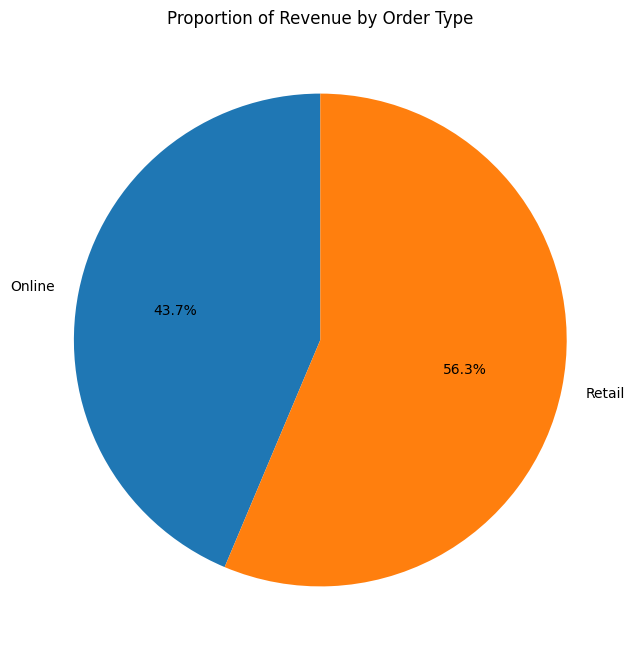

In [51]:
revenue_by_order_type = df.groupby('order_type')['total_amount'].sum()
plt.figure(figsize=(8, 8))
plt.pie(revenue_by_order_type, labels=revenue_by_order_type.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Revenue by Order Type')
plt.show()

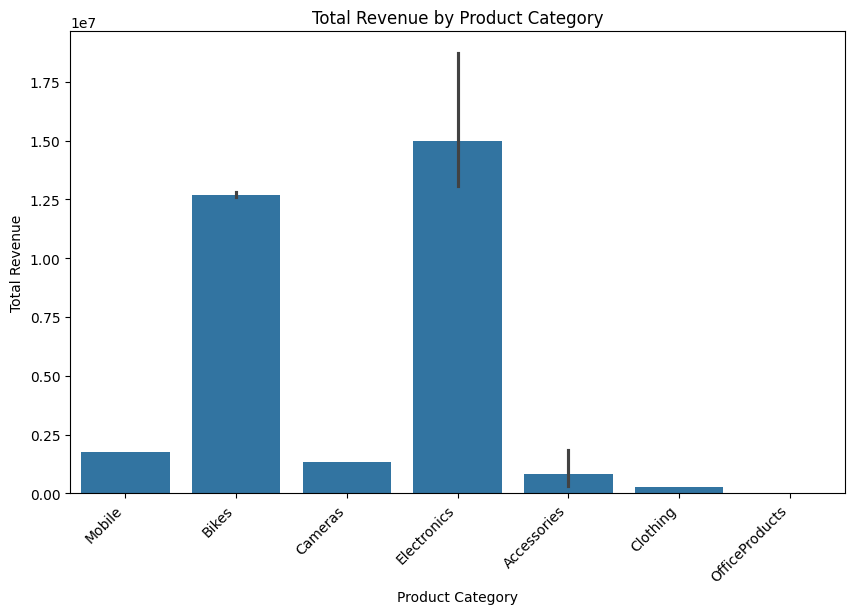

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x='product_line', y='total_amount', data=df, estimator=sum)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.show()

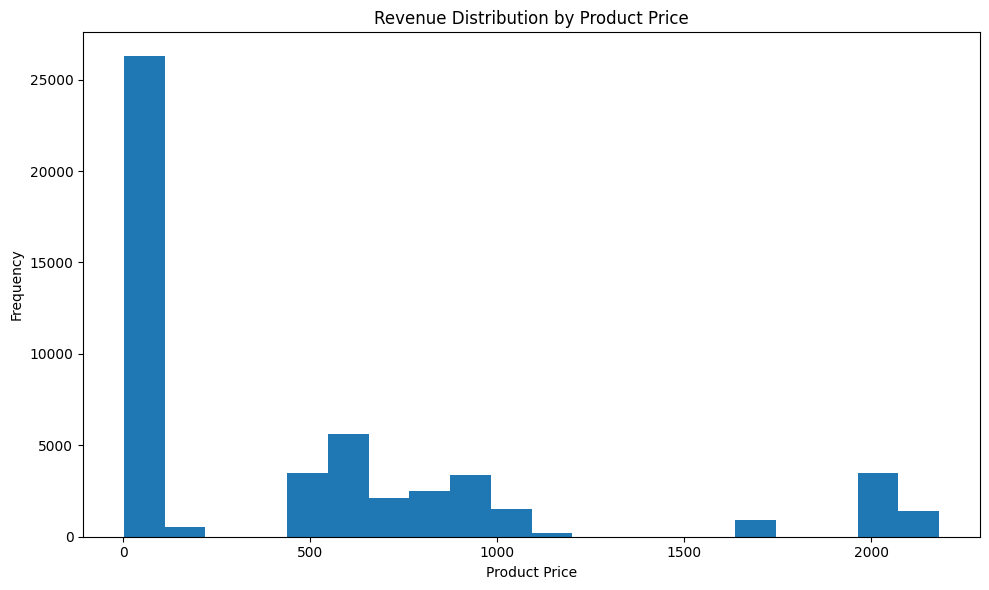

In [53]:
# Chart 3: Revenue Distribution by Product Price (Histogram)
plt.figure(figsize=(10, 6))
plt.hist(df['product_price'], bins=20)
plt.title('Revenue Distribution by Product Price')
plt.xlabel('Product Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Covariance

➡️ Assignment Task
- Create a covariance matrix using all of the applicable independent variables
- In 100 words or less, describe what insight you can derive from the covariance matrix.  What does it tell us about the data?  


In [54]:
# Select numerical columns for covariance calculation
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_df = df[numerical_cols]

# Calculate the covariance matrix
covariance_matrix = numerical_df.cov()

# Display the covariance matrix
covariance_matrix


,order_id,quantity,product_price,total_amount
order_id,5.191474e+07,9.888280e+03,-821314.245733,-5.738648e+05
quantity,9.888280e+03,1.944211e+05,-1130.924209,1.039495e+06
product_price,-8.213142e+05,-1.130924e+03,416182.307363,4.386580e+05
total_amount,-5.738648e+05,1.039495e+06,438658.008563,7.031612e+07


The covariance matrix reveals relationships between key variables in the dataset. A strong positive covariance between `quantity` and `total_amount` indicates that higher order volumes lead to increased sales. Similarly, `product_price` and `total_amount` show a positive relationship, suggesting that higher-priced products contribute more to revenue. However, the negative covariance between `product_price` and `quantity` implies that as prices rise, order volumes may decrease. The presence of negative variance for `product_price` suggests possible data inconsistencies. Overall, the matrix highlights expected trends in sales data but may require further validation for potential outliers or data type issues.